In [ ]:
# Survey on Digital Learning Tools Among College Students
### A Data Analysis Project — Pandas, NumPy & Matplotlib

**Prepared by:** Ganesh Waghmare
**Course:** BSc Data Science, New Arts, Commerce and Science College, Ahmednagar
**Dataset:** `survey_data.xlsx` — 69 responses, 22 fields

---
This notebook performs a complete, end-to-end analysis of a student-conducted survey on digital
learning tool usage: data cleaning, descriptive statistics, cross-tabulations, correlation
analysis, and 20+ visualizations, followed by a summary of key findings.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

In [5]:
raw = pd.read_csv("C:/Users/hp/Downloads/raw_data.csv")
print(f"Shape: {raw.shape}")
raw.head()


Shape: (69, 22)


,S.NO,Submitted Time,1. Full Name,2. Age,3. Gender,4. Year of study,5. Do you use digital learning tools for your studies?,6. Which digital learning tools do you use?,7. How frequently do you use digital learning tools?,8. how much time do you spend using digital learning tools for academic purposes per day?,...,11. what do you consider the biggest advantage of digital learning tools,12. what problem do you face while using digital learning tools?,13. What device do you mainly use for digital learning?,14. Where do mainly access digital learning tools?,15. Which digital learning tools do you consider most useful for your academic learning?,16. How accurate and reliable do you find the information provided by digital learning tools?,17. How would you rate your overall experience with digital learning tools for your academic studies?,18. Which type of learning do you think is more costly?,"19. Compared to offline learning, how do you find the cost of digital learning tools?",20. What is your primary purpose for using AI tools?
0,1,8/21/2026 18:50,Waghmare Ganesh Jalindar,19,Male,SY Data science,Yes,Youtube | Zoom | ChatGPT/AI tools | Cloude,Daily,1-2 hours,...,All of the above,Paid/Limited features,Smartphone,Home,ChatGPT,Highly accurate,Excellent,Depends on the course/institute,Almost the same,Coding / Programming debugging and help
1,2,8/22/2026 13:27,Najan Pranali Anil,19,Female,SY Data science,Yes,ChatGPT/AI tools,2-3 days a week,30 minutes -1 hours,...,Easy explanation of difficult concept,Paid/Limited features,Smartphone,Hostel,ChatGPT,Moderately inaccurate,Average,Digital Learning Tools,Slightly more expensive,Coding / Programming debugging and help
2,3,8/22/2026 13:28,Phatangare Sarthak Malhari,18,Male,SY Data science,Yes,Youtube | Google Meet | ChatGPT/AI tools | ...,Daily,1-2 hours,...,All of the above,Paid/Limited features,Smartphone,Hostel,ChatGPT | Gemini,Highly accurate,Excellent,Offline Learning,Slightly cheaper,Preparing assignments and project reports
3,4,8/22/2026 15:02,Khilari Yogesh Gulab,18,Male,SY Data science,Yes,ChatGPT/AI tools,Daily,30 minutes -1 hours,...,Save time,Paid/Limited features,Smartphone,Home,ChatGPT,Highly accurate,Excellent,Digital Learning Tools,Much more expensive,Clearing doubts and complex concepts
4,5,8/22/2026 15:36,Vedanti Nitin Athare,19,Female,SY Data science,Yes,Youtube | Google Classroom | Google Meet | ...,4-6 days a week,30 minutes -1 hours,...,Easy revision through recorded lectures,Paid/Limited features,Laptop,Home,ChatGPT | cloude | Gemini,Accurate,Good,Depends on the course/institute,Slightly cheaper,Clearing doubts and complex concepts


In [6]:
raw.tail()

,S.NO,Submitted Time,1. Full Name,2. Age,3. Gender,4. Year of study,5. Do you use digital learning tools for your studies?,6. Which digital learning tools do you use?,7. How frequently do you use digital learning tools?,8. how much time do you spend using digital learning tools for academic purposes per day?,...,11. what do you consider the biggest advantage of digital learning tools,12. what problem do you face while using digital learning tools?,13. What device do you mainly use for digital learning?,14. Where do mainly access digital learning tools?,15. Which digital learning tools do you consider most useful for your academic learning?,16. How accurate and reliable do you find the information provided by digital learning tools?,17. How would you rate your overall experience with digital learning tools for your academic studies?,18. Which type of learning do you think is more costly?,"19. Compared to offline learning, how do you find the cost of digital learning tools?",20. What is your primary purpose for using AI tools?
64,65,8/28/2026 11:25,Thorat omkar namdev,20,Male,TY computer science,Yes,ChatGPT/AI tools,4-6 days a week,Less than 30 minutes,...,Easy and quick Access to information,incorrect or misleading information,Smartphone,College,ChatGPT,Accurate,Good,Offline Learning,Much more expensive,Clearing doubts and complex concepts
65,66,9/2/2026 19:52,Answer,18,Male,FY Data science,Yes,Youtube,Daily,Less than 30 minutes,...,Easy and quick Access to information,Internet connectivity issues,Smartphone,Home,ChatGPT,Highly accurate,Excellent,Digital Learning Tools,Slightly more expensive,Clearing doubts and complex concepts
66,67,9/2/2026 20:21,Ashis Dehury,18,Male,BA (others),Yes,ChatGPT/AI tools | Youtube | Coursera,Daily,More than 3 hours,...,All of the above,Internet connectivity issues,Smartphone,Home,ChatGPT,Accurate,Average,Offline Learning,Much more expensive,Coding / Programming debugging and help
67,68,9/4/2026 15:29,Ankita Nehariya,26,Female,"M.s.c CS, Data Science (others)",Yes,Google Meet | ChatGPT/AI tools | Youtube,Daily,2-3 hours,...,Easy explanation of difficult concept,Internet connectivity issues,Laptop,Home,ChatGPT | Gemini,Accurate,Excellent,Offline Learning,Slightly more expensive,Clearing doubts and complex concepts
68,69,9/7/2026 14:51,Aadesh Balasaheb Patankar,20,Male,SY Data science,Yes,Youtube,Daily,1-2 hours,...,Flexibility to study anytime and anywhere,Paid/Limited features,Laptop,College,Gemini,Neutral / Moderately accurate,Very Poor,Offline Learning,Slightly more expensive,Coding / Programming debugging and help


In [7]:
df = raw.copy()
df.columns = [c.strip() for c in df.columns]

rename_map = {
    "S.NO": "sno",
    "Submitted Time": "submitted_time",
    "1.  Full Name": "name",
    "2. Age": "age",
    "3. Gender": "gender",
    "4. Year of study": "year_of_study",
    "5. Do you use digital learning tools for your studies?": "uses_tools",
    "6. Which digital learning tools do you use?": "tools_used",
    "7. How frequently do you use digital learning tools?": "frequency",
    "8. how much time do you spend using digital learning tools for academic purposes per day?": "time_per_day",
    "9. How much do digital learning tools help you in your studies": "helpfulness",
    "10. What is the main benefits you get from digital learning tools?": "main_benefit",
    "11. what do you consider the biggest advantage of digital learning tools": "biggest_advantage",
    "12. what problem do you face while using digital learning tools?": "problem_faced",
    "13. What device do you mainly use for digital learning?": "device",
    "14. Where do mainly access digital learning tools?": "access_location",
    "15. Which digital learning tools do you consider most useful for your academic learning?": "most_useful_tools",
    "16. How accurate and reliable do you find the information provided by digital learning tools?": "accuracy_rating",
    "17. How would you rate your overall experience with digital learning tools for your academic studies?": "overall_experience",
    "18. Which type of learning do you think is more costly?": "costlier_learning_type",
    "19. Compared to offline learning, how do you find the cost of digital learning tools?": "cost_comparison",
    "20. What is your primary purpose for using AI tools?": "ai_purpose",
}
df = df.rename(columns=rename_map)

for c in df.columns:
    if df[c].dtype == object or str(df[c].dtype) == "string":
        df[c] = df[c].astype(str).str.strip()

df_analysis = df.drop(columns=["name"])   # drop PII for analysis
df_analysis["year_of_study"] = df_analysis["year_of_study"].str.replace(r"\s*\(others\)", "", regex=True).str.strip()

print("Missing values per column:")
print(df_analysis.isna().sum().loc[lambda s: s > 0] if df_analysis.isna().sum().sum() else "None")
print(f"\nDuplicate response rows: {df_analysis.duplicated(subset=[c for c in df_analysis.columns if c not in ('sno','submitted_time')]).sum()}")
df_analysis.head()


Missing values per column:
None

Duplicate response rows: 1


,sno,submitted_time,age,gender,year_of_study,uses_tools,tools_used,frequency,time_per_day,helpfulness,...,biggest_advantage,problem_faced,device,access_location,most_useful_tools,accuracy_rating,overall_experience,costlier_learning_type,cost_comparison,ai_purpose
0,1,8/21/2026 18:50,19,Male,SY Data science,Yes,Youtube | Zoom | ChatGPT/AI tools | Cloude,Daily,1-2 hours,Extremely helpful,...,All of the above,Paid/Limited features,Smartphone,Home,ChatGPT,Highly accurate,Excellent,Depends on the course/institute,Almost the same,Coding / Programming debugging and help
1,2,8/22/2026 13:27,19,Female,SY Data science,Yes,ChatGPT/AI tools,2-3 days a week,30 minutes -1 hours,slightly helpful,...,Easy explanation of difficult concept,Paid/Limited features,Smartphone,Hostel,ChatGPT,Moderately inaccurate,Average,Digital Learning Tools,Slightly more expensive,Coding / Programming debugging and help
2,3,8/22/2026 13:28,18,Male,SY Data science,Yes,Youtube | Google Meet | ChatGPT/AI tools | ...,Daily,1-2 hours,Extremely helpful,...,All of the above,Paid/Limited features,Smartphone,Hostel,ChatGPT | Gemini,Highly accurate,Excellent,Offline Learning,Slightly cheaper,Preparing assignments and project reports
3,4,8/22/2026 15:02,18,Male,SY Data science,Yes,ChatGPT/AI tools,Daily,30 minutes -1 hours,Very helpful,...,Save time,Paid/Limited features,Smartphone,Home,ChatGPT,Highly accurate,Excellent,Digital Learning Tools,Much more expensive,Clearing doubts and complex concepts
4,5,8/22/2026 15:36,19,Female,SY Data science,Yes,Youtube | Google Classroom | Google Meet | ...,4-6 days a week,30 minutes -1 hours,Very helpful,...,Easy revision through recorded lectures,Paid/Limited features,Laptop,Home,ChatGPT | cloude | Gemini,Accurate,Good,Depends on the course/institute,Slightly cheaper,Clearing doubts and complex concepts


In [8]:
age = df_analysis["age"].to_numpy()
age_stats = {
    "count": age.size,
    "mean": np.mean(age),
    "median": np.median(age),
    "std_dev": np.std(age, ddof=1),
    "min": np.min(age),
    "max": np.max(age),
}
for k, v in age_stats.items():
    print(f"{k:>10}: {round(v, 2) if isinstance(v, (float, np.floating)) else v}")


     count: 69
      mean: 19.93
    median: 19.0
   std_dev: 1.87
       min: 18
       max: 26


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sno,69.0,35.000000,20.062403,1.0,18.0,35.0,52.0,69.0
age,69.0,19.927536,1.865467,18.0,19.0,19.0,20.0,26.0


In [10]:
df.describe()

,sno,age
count,69.000000,69.000000
mean,35.000000,19.927536
std,20.062403,1.865467
min,1.000000,18.000000
25%,18.000000,19.000000
50%,35.000000,19.000000
75%,52.000000,20.000000
max,69.000000,26.000000


In [11]:
gender_counts = df_analysis["gender"].value_counts()
year_counts = df_analysis["year_of_study"].value_counts()
uses_counts = df_analysis["uses_tools"].value_counts()

freq_order = ["Daily", "4-6 days a week", "2-3 days a week", "Once a week", "Rarely"]
freq_counts = df_analysis["frequency"].value_counts().reindex(freq_order).fillna(0).astype(int)

time_order = ["Less than 30 minutes", "30 minutes -1 hours", "1-2 hours", "2-3 hours", "More than 3 hours"]
time_counts = df_analysis["time_per_day"].value_counts().reindex(time_order).fillna(0).astype(int)

help_order = ["slightly helpful", "Moderately helpful", "Very helpful", "Extremely helpful"]
help_counts = df_analysis["helpfulness"].value_counts().reindex(help_order).fillna(0).astype(int)

device_counts = df_analysis["device"].value_counts()
access_counts = df_analysis["access_location"].value_counts()
problem_counts = df_analysis["problem_faced"].value_counts()

accuracy_order = ["Very inaccurate", "Moderately inaccurate", "Neutral / Moderately accurate", "Accurate", "Highly accurate"]
accuracy_counts = df_analysis["accuracy_rating"].value_counts().reindex(accuracy_order).fillna(0).astype(int)

experience_order = ["Very Poor", "Poor", "Average", "Good", "Excellent"]
experience_counts = df_analysis["overall_experience"].value_counts().reindex(experience_order).fillna(0).astype(int)

cost_type_counts = df_analysis["costlier_learning_type"].value_counts()
cost_cmp_counts = df_analysis["cost_comparison"].value_counts()
ai_purpose_counts = df_analysis["ai_purpose"].value_counts()
advantage_counts = df_analysis["biggest_advantage"].value_counts()

print("Frequency of use:\n", freq_counts, "\n")
print("Overall experience:\n", experience_counts)


Frequency of use:
 frequency
Daily              41
4-6 days a week    14
2-3 days a week     8
Once a week         5
Rarely              1
Name: count, dtype: int64 

Overall experience:
 overall_experience
Very Poor     4
Poor          2
Average       6
Good         24
Excellent    33
Name: count, dtype: int64


In [12]:
def split_multi(series):
    items = []
    for val in series.dropna():
        for part in str(val).split("|"):
            part = part.strip()
            if part and part.lower() != "nan":
                items.append(part)
    return Counter(items)

tools_used_counts = pd.Series(split_multi(df_analysis["tools_used"])).sort_values(ascending=False)
most_useful_counts = pd.Series(split_multi(df_analysis["most_useful_tools"])).sort_values(ascending=False)
benefit_counts = pd.Series(split_multi(df_analysis["main_benefit"])).sort_values(ascending=False)

tools_used_counts


Youtube             47
ChatGPT/AI tools    47
Google Classroom    27
Cloude              18
Google Meet         16
Education apps      16
Zoom                13
Duolingo            10
Coursera             8
Udemy (others)       1
dtype: int64

In [13]:
freq_map = {"Rarely": 1, "Once a week": 2, "2-3 days a week": 3, "4-6 days a week": 4, "Daily": 5}
help_map = {"slightly helpful": 1, "Moderately helpful": 2, "Very helpful": 3, "Extremely helpful": 4}
exp_map  = {"Very Poor": 1, "Poor": 2, "Average": 3, "Good": 4, "Excellent": 5}
acc_map  = {"Very inaccurate": 1, "Moderately inaccurate": 2, "Neutral / Moderately accurate": 3, "Accurate": 4, "Highly accurate": 5}

df_analysis["freq_score"] = df_analysis["frequency"].map(freq_map)
df_analysis["help_score"] = df_analysis["helpfulness"].map(help_map)
df_analysis["exp_score"]  = df_analysis["overall_experience"].map(exp_map)
df_analysis["acc_score"]  = df_analysis["accuracy_rating"].map(acc_map)

corr_matrix = df_analysis[["age", "freq_score", "help_score", "acc_score", "exp_score"]].corr(numeric_only=True)
corr_matrix.round(2)


,age,freq_score,help_score,acc_score,exp_score
age,1.00,0.23,0.02,0.16,0.19
freq_score,0.23,1.00,0.05,0.33,0.53
help_score,0.02,0.05,1.00,-0.06,-0.02
acc_score,0.16,0.33,-0.06,1.00,0.69
exp_score,0.19,0.53,-0.02,0.69,1.00


In [14]:
gender_vs_experience = pd.crosstab(df_analysis["gender"], df_analysis["overall_experience"])
freq_vs_helpfulness  = pd.crosstab(df_analysis["frequency"], df_analysis["helpfulness"])
device_vs_experience = pd.crosstab(df_analysis["device"], df_analysis["overall_experience"])
freq_vs_helpfulness


helpfulness,Extremely helpful,Moderately helpful,Very helpful,slightly helpful
frequency,,,,
2-3 days a week,0,2,5,1
4-6 days a week,1,3,8,2
Daily,9,4,22,6
Once a week,0,2,3,0
Rarely,1,0,0,0


In [17]:
import seaborn as sns

# Color palette definition add
PALETTE = sns.color_palette("Set2")  # or custom hex code list: ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

In [21]:
def barh_chart(counts, title, xlabel="Number of Respondents", color=None):
    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(counts) + 1)))
    counts_sorted = counts.sort_values(ascending=True)
    bars = ax.barh(counts_sorted.index.astype(str), counts_sorted.values, color=color or PALETTE[0])
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for bar, val in zip(bars, counts_sorted.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(int(val)), va="center", fontsize=9)
    fig.tight_layout()
    plt.show()

def pie_chart(counts, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = PALETTE[:len(counts)]
    wedges, texts, autotexts = ax.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%",
                                       colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.2})
    for t in autotexts:
        t.set_fontsize(9); t.set_color("white"); t.set_fontweight("bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    fig.tight_layout()
    plt.show()

def bar_chart_ordered(counts, title, xlabel="", ylabel="Number of Respondents", color=None, rotate=20):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(counts.index.astype(str), counts.values, color=color or PALETTE[1])
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.setp(ax.get_xticklabels(), rotation=rotate, ha="right")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.2, str(int(val)), ha="center", fontsize=9)
    fig.tight_layout()
    plt.show()


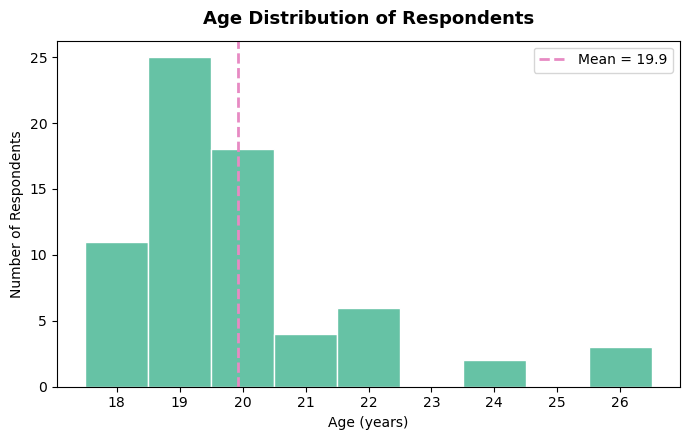

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.arange(age.min(), age.max() + 2) - 0.5
ax.hist(age, bins=bins, color=PALETTE[0], edgecolor="white")
ax.set_title("Age Distribution of Respondents", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Age (years)"); ax.set_ylabel("Number of Respondents")
ax.set_xticks(np.arange(age.min(), age.max() + 1))
ax.axvline(age_stats["mean"], color=PALETTE[3], linestyle="--", linewidth=2, label=f"Mean = {age_stats['mean']:.1f}")
ax.legend()
fig.tight_layout()
plt.show()


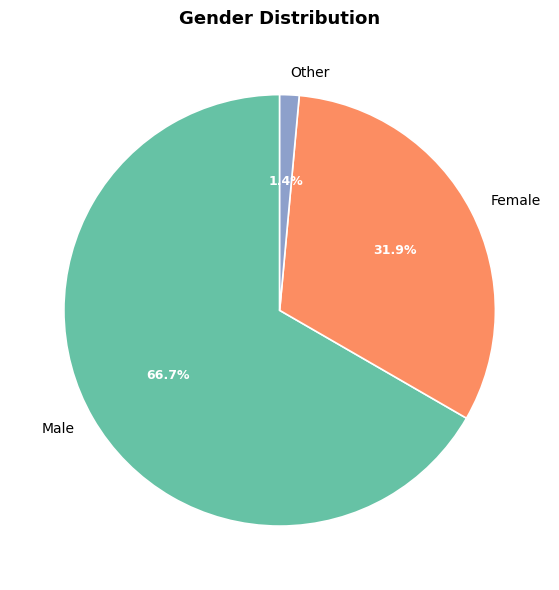

In [20]:
pie_chart(gender_counts, "Gender Distribution")

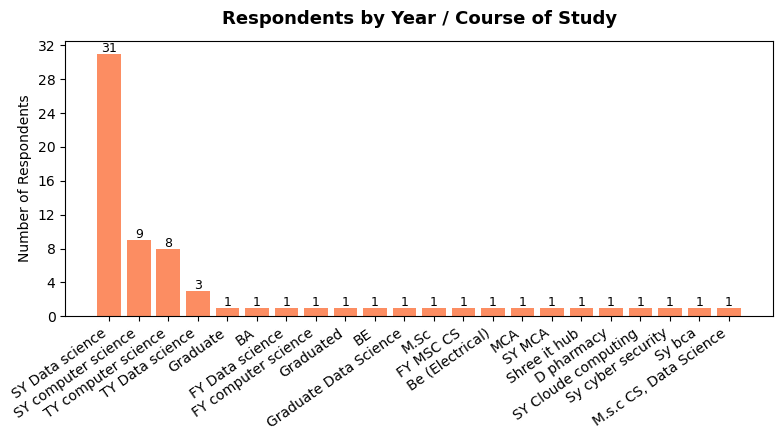

In [22]:
bar_chart_ordered(year_counts, "Respondents by Year / Course of Study", rotate=35)

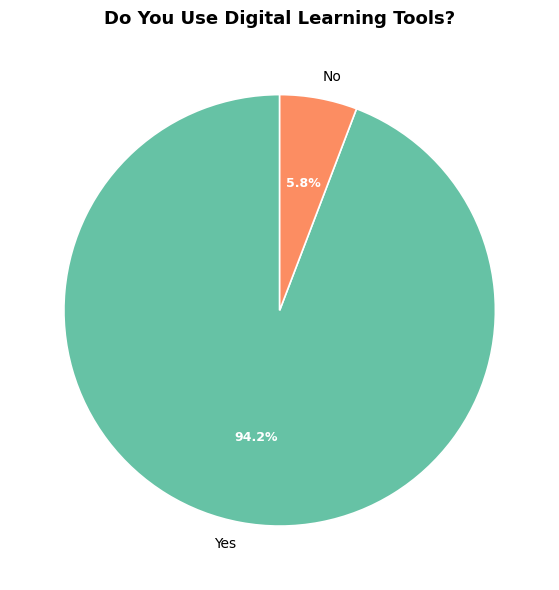

In [23]:
pie_chart(uses_counts, "Do You Use Digital Learning Tools?")

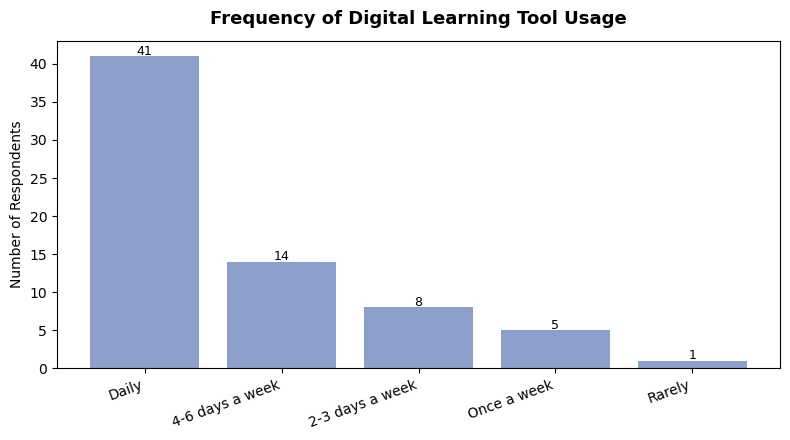

In [24]:
bar_chart_ordered(freq_counts, "Frequency of Digital Learning Tool Usage", rotate=20, color=PALETTE[2])

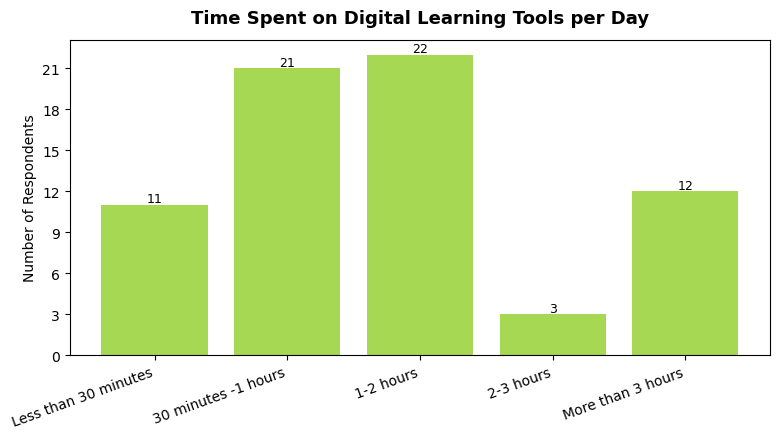

In [25]:
bar_chart_ordered(time_counts, "Time Spent on Digital Learning Tools per Day", rotate=20, color=PALETTE[4])

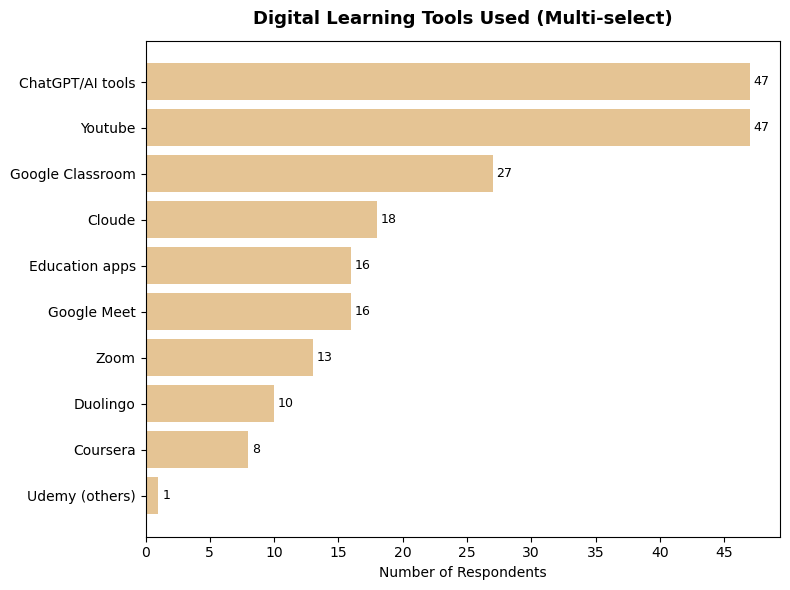

In [26]:
barh_chart(tools_used_counts, "Digital Learning Tools Used (Multi-select)", color=PALETTE[6])

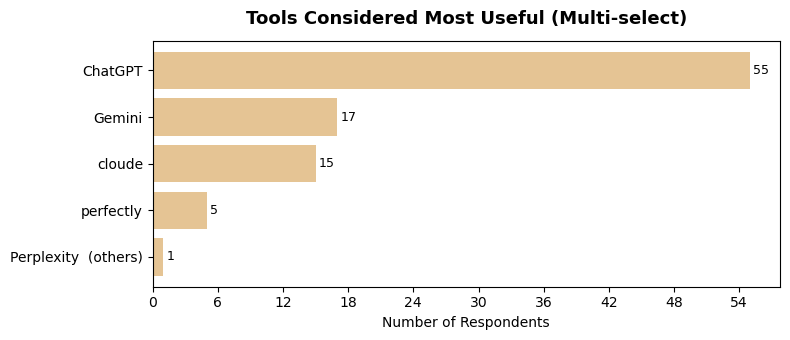

In [27]:
barh_chart(most_useful_counts, "Tools Considered Most Useful (Multi-select)", color=PALETTE[6])

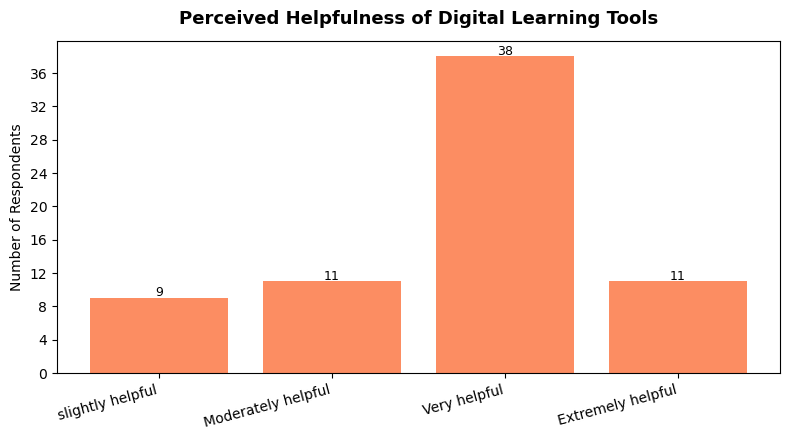

In [28]:
bar_chart_ordered(help_counts, "Perceived Helpfulness of Digital Learning Tools", rotate=15, color=PALETTE[1])

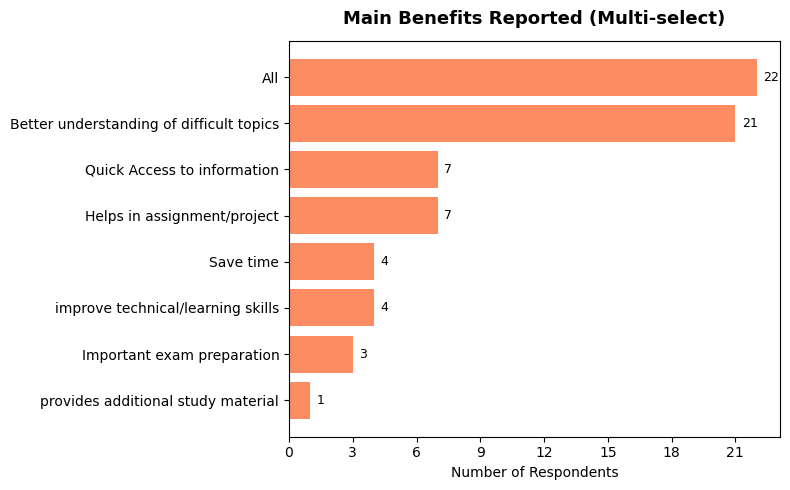

In [29]:
barh_chart(benefit_counts, "Main Benefits Reported (Multi-select)", color=PALETTE[1])

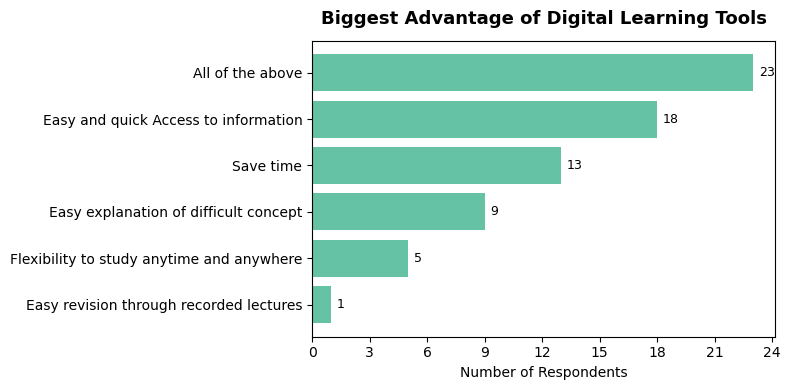

In [30]:
barh_chart(advantage_counts, "Biggest Advantage of Digital Learning Tools", color=PALETTE[0])

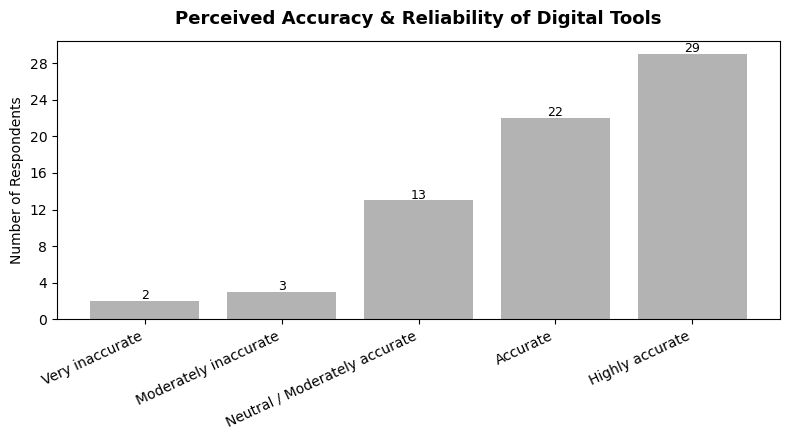

In [31]:
bar_chart_ordered(accuracy_counts, "Perceived Accuracy & Reliability of Digital Tools", rotate=25, color=PALETTE[7])

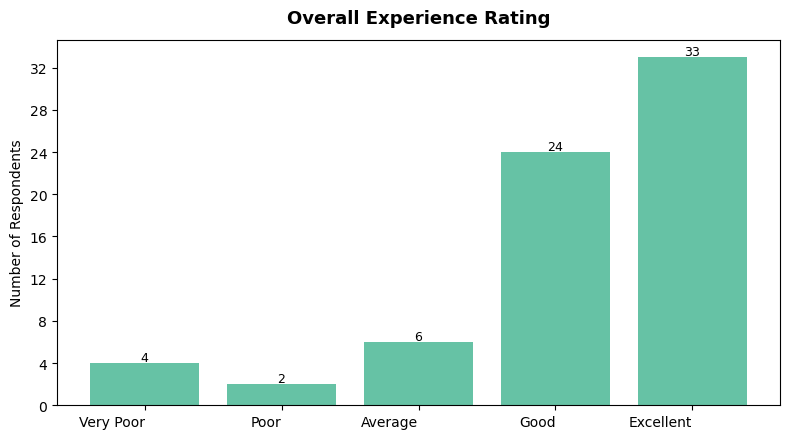

In [32]:
bar_chart_ordered(experience_counts, "Overall Experience Rating", rotate=0, color=PALETTE[0])

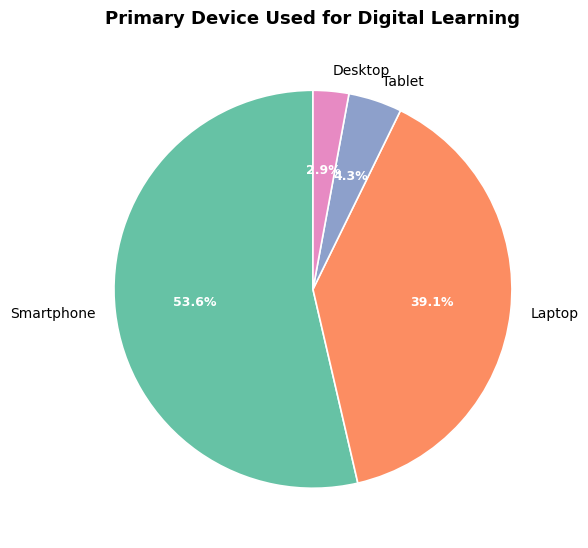

In [33]:
pie_chart(device_counts, "Primary Device Used for Digital Learning")

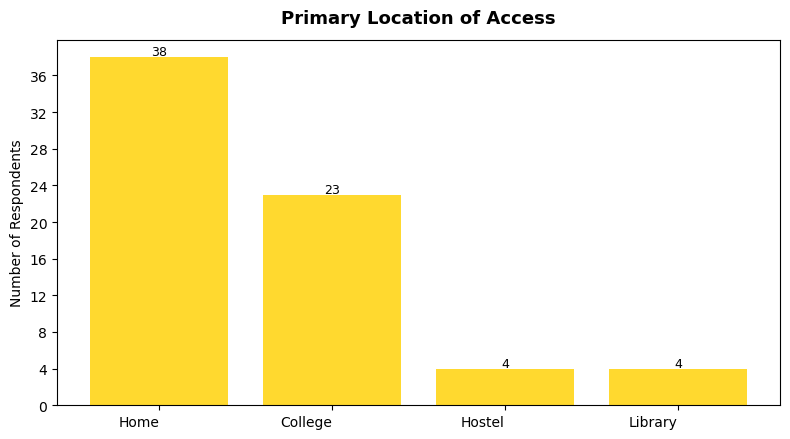

In [34]:
bar_chart_ordered(access_counts, "Primary Location of Access", rotate=0, color=PALETTE[5])

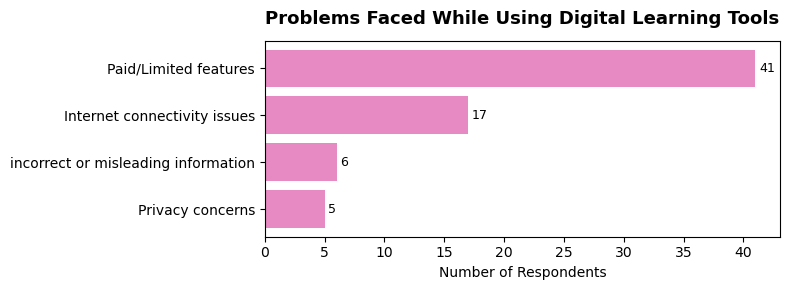

In [35]:
barh_chart(problem_counts, "Problems Faced While Using Digital Learning Tools", color=PALETTE[3])

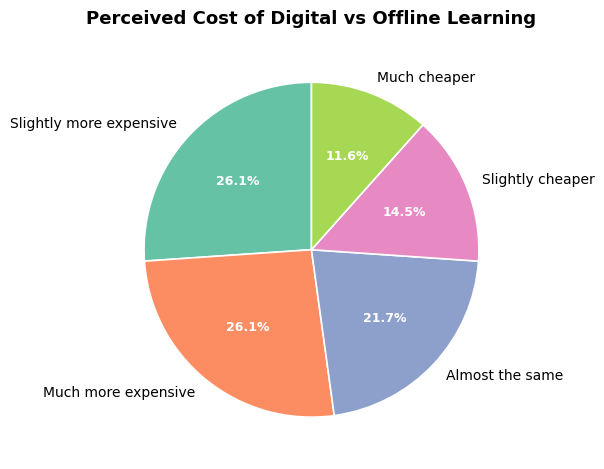

In [36]:
pie_chart(cost_cmp_counts, "Perceived Cost of Digital vs Offline Learning")

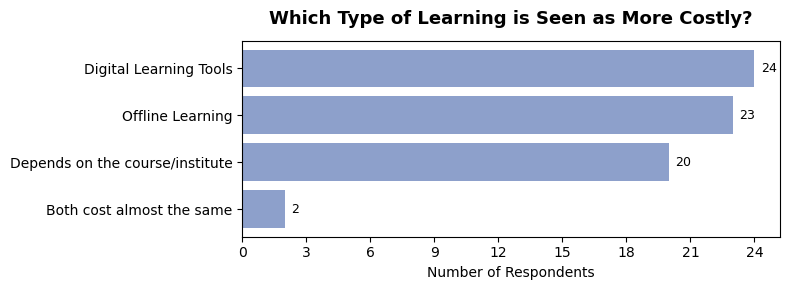

In [37]:
barh_chart(cost_type_counts, "Which Type of Learning is Seen as More Costly?", color=PALETTE[2])

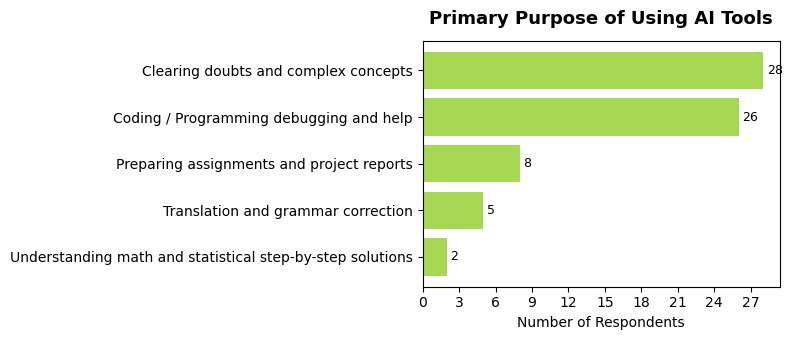

In [38]:
barh_chart(ai_purpose_counts, "Primary Purpose of Using AI Tools", color=PALETTE[4])

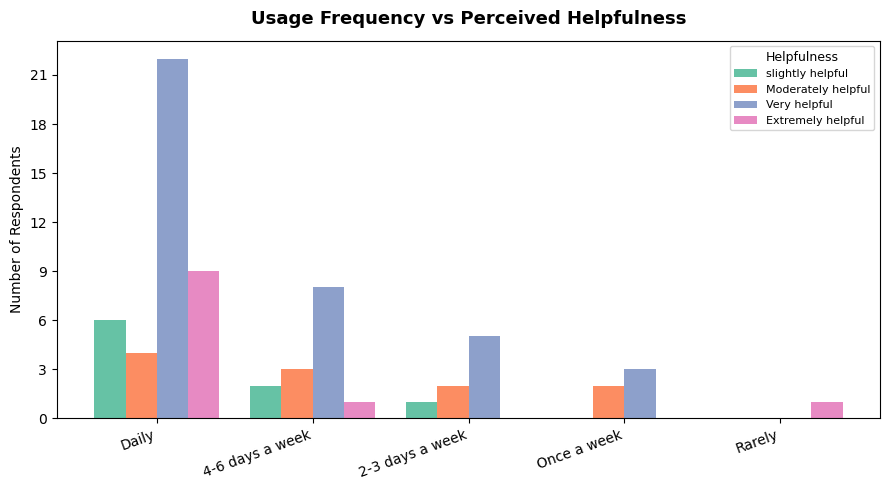

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
ftab = freq_vs_helpfulness.reindex(index=freq_order, columns=help_order).fillna(0)
x = np.arange(len(ftab.index))
width = 0.2
for i, col in enumerate(ftab.columns):
    ax.bar(x + i*width, ftab[col].values, width, label=col, color=PALETTE[i % len(PALETTE)])
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(ftab.index, rotation=20, ha="right")
ax.set_ylabel("Number of Respondents")
ax.set_title("Usage Frequency vs Perceived Helpfulness", fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Helpfulness", fontsize=8, title_fontsize=9)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
plt.show()


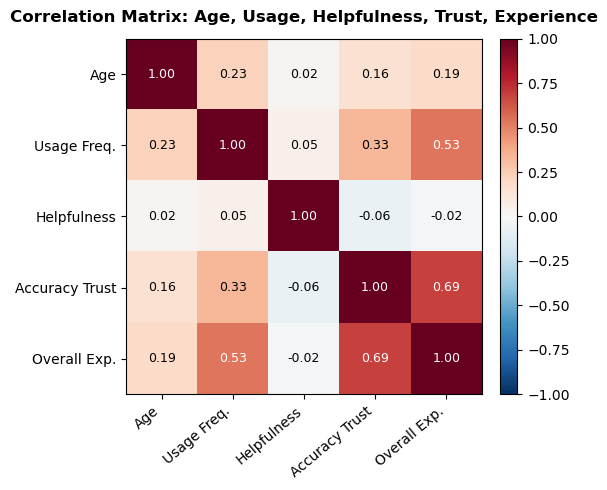

In [40]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
labels = ["Age", "Usage Freq.", "Helpfulness", "Accuracy Trust", "Overall Exp."]
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=40, ha="right"); ax.set_yticklabels(labels)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.values[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix.values[i,j]) > 0.5 else "black", fontsize=9)
ax.set_title("Correlation Matrix: Age, Usage, Helpfulness, Trust, Experience", fontsize=12, fontweight="bold", pad=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


In [41]:
n_rows = len(df_analysis)
pct_uses = round(uses_counts.get("Yes", 0) / n_rows * 100, 1)
pct_daily_or_more = round((freq_counts.get("Daily", 0) + freq_counts.get("4-6 days a week", 0)) / n_rows * 100, 1)
pct_helpful = round((help_counts.get("Very helpful", 0) + help_counts.get("Extremely helpful", 0)) / n_rows * 100, 1)
pct_good_exp = round((experience_counts.get("Good", 0) + experience_counts.get("Excellent", 0)) / n_rows * 100, 1)

print(f"Total respondents               : {n_rows}")
print(f"Average age                     : {age_stats['mean']:.1f} years (range {age_stats['min']}-{age_stats['max']})")
print(f"Use digital learning tools       : {pct_uses}%")
print(f"Use tools daily / 4-6 days/week  : {pct_daily_or_more}%")
print(f"Most used tool                   : {tools_used_counts.idxmax()}")
print(f"Find tools Very/Extremely helpful: {pct_helpful}%")
print(f"Top reported benefit             : {benefit_counts.idxmax()}")
print(f"Top problem faced                : {problem_counts.idxmax()}")
print(f"Most used device                 : {device_counts.idxmax()}")
print(f"Rate experience Good/Excellent   : {pct_good_exp}%")
print(f"Top AI tool purpose              : {ai_purpose_counts.idxmax()}")
print(f"Correlation (Usage freq ↔ Exp.)  : {corr_matrix.loc['freq_score','exp_score']:.2f}")
print(f"Correlation (Trust ↔ Exp.)       : {corr_matrix.loc['acc_score','exp_score']:.2f}")


Total respondents               : 69
Average age                     : 19.9 years (range 18-26)
Use digital learning tools       : 94.2%
Use tools daily / 4-6 days/week  : 79.7%
Most used tool                   : Youtube
Find tools Very/Extremely helpful: 71.0%
Top reported benefit             : All
Top problem faced                : Paid/Limited features
Most used device                 : Smartphone
Rate experience Good/Excellent   : 82.6%
Top AI tool purpose              : Clearing doubts and complex concepts
Correlation (Usage freq ↔ Exp.)  : 0.53
Correlation (Trust ↔ Exp.)       : 0.69


In [44]:
df.to_csv("ganesh.csv")